In [ ]:
import numpy as np
import pandas as pd
df=pd.read_table('diabetes.tsv')
print(df)
df.info()

df.describe()

     AGE  SEX   BMI      BP   S1     S2    S3    S4      S5   S6    Y
0     59    2  32.1  101.00  157   93.2  38.0  4.00  4.8598   87  151
1     48    1  21.6   87.00  183  103.2  70.0  3.00  3.8918   69   75
2     72    2  30.5   93.00  156   93.6  41.0  4.00  4.6728   85  141
3     24    1  25.3   84.00  198  131.4  40.0  5.00  4.8903   89  206
4     50    1  23.0  101.00  192  125.4  52.0  4.00  4.2905   80  135
..   ...  ...   ...     ...  ...    ...   ...   ...     ...  ...  ...
437   60    2  28.2  112.00  185  113.8  42.0  4.00  4.9836   93  178
438   47    2  24.9   75.00  225  166.0  42.0  5.00  4.4427  102  104
439   60    2  24.9   99.67  162  106.6  43.0  3.77  4.1271   95  132
440   36    1  30.0   95.00  201  125.2  42.0  4.79  5.1299   85  220
441   36    1  19.6   71.00  250  133.2  97.0  3.00  4.5951   92   57

[442 rows x 11 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  D

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


<Axes: >

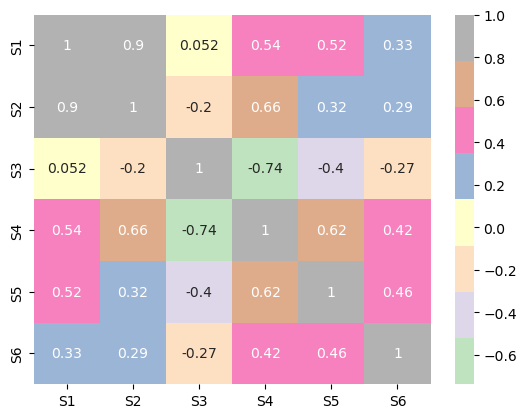

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
df1=df[['S1','S2','S3','S4','S5','S6']].corr()
sns.heatmap(df1,annot=True,cmap='Accent',alpha=0.5)



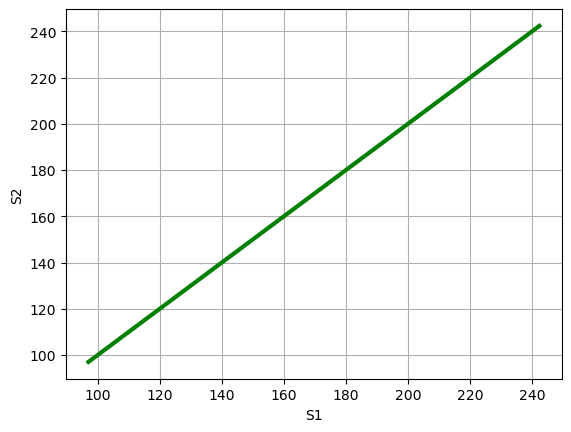

In [30]:
plt.plot([df['S1'].min(),df['S2'].max()],[df['S1'].min(),df['S2'].max()],color='green',linewidth=3)
plt.xlabel('S1')
plt.ylabel('S2')
plt.grid(True)

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score
X=df.drop('Y',axis=1)
y=df['Y']
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)
model=RandomForestRegressor(max_depth=4,min_samples_leaf=5,min_samples_split=5,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(y_pred)
print("Mean absolute error",mean_absolute_error(y_test,y_pred))
print("R2 score:",r2_score(y_test,y_pred))

[159.19825797 170.91487188 162.01038403 246.34069622 118.47478815
 104.57238842 230.02925364 214.28527565 145.40812622 175.87724456
 100.4223645  169.70712436  92.17826661 233.20770618  96.18382716
 131.28097466 240.77549431 255.08561487 185.30728073 228.30111292
 181.54548067 109.21929371  82.47481322 201.03725558 154.97853088
 183.84556238 183.91495348 142.45886634  81.20746595 108.38493666
 182.36604513  89.88909188 174.20438248 196.17878408 161.04704678
 217.5881745  122.97633791 128.82193882 170.19579191  83.43065775
  84.22086995 103.33284425 148.44070745 152.44347915 169.37760061
  85.20639243  83.31389905 108.09485941  83.11677476 162.89964745
 129.24627718  85.32332274 163.54890159  98.00808585 184.50583224
 148.95867302  97.72573179 214.66264679  96.59061732  94.97855333
 180.03281659 182.43159285 151.7504561   99.72718686 136.79719766
 211.80622824 183.68499941 175.9182429  119.98369955 148.90509177
 182.94395349 199.02060197 204.05482554 113.63796955  85.33742392
 160.64734